In [36]:
import warnings

warnings.filterwarnings("ignore")

import os

import pycountry
import plotly.express as px
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, fbeta_score, make_scorer, PrecisionRecallDisplay

from sklearn.calibration import CalibrationDisplay


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 45
np.random.seed(RANDOM_STATE)

CUR_DIR = os.getcwd()
BOOKS_DATA_PATH = os.path.join(CUR_DIR, "books_data/books.csv")
RATINGS_DATA_PATH = os.path.join(CUR_DIR, "books_data/ratings.csv")
USERS_DATA_PATH = os.path.join(CUR_DIR, "books_data/users.csv")

df_books = pd.read_csv(BOOKS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"', escapechar="\\").drop(columns = ['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])
df_ratings = pd.read_csv(RATINGS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"')
df_users = pd.read_csv(USERS_DATA_PATH, encoding = 'latin-1', sep = ';', quotechar='"', escapechar="\\", index_col=0)

print(f"Books data    loaded {len(df_books):,} rows, {df_books.shape[1]} columns.")
print(f"Ratings data  loaded {len(df_ratings):,} rows, {df_ratings.shape[1]} columns.")
print(f"Users data    loaded {len(df_users):,} rows, {df_users.shape[1]} columns.")

df_active_countries = df_users['Location'].str.split(',').str[-1].str.strip()
unique_active_countries = df_active_countries.unique()

Books data    loaded 271,379 rows, 5 columns.
Ratings data  loaded 1,149,780 rows, 3 columns.
Users data    loaded 278,858 rows, 2 columns.


In [37]:
"""
METHOD 1
"""
countries = []
for country in pycountry.countries:
    countries.append(country.name.lower())

mutual = []
for mutual_country in countries:
    if mutual_country in unique_active_countries:
        mutual.append(mutual_country)

#ADD MANUALLY countries not in mutual
mutual += "usa", "russia", "iran", "vietnam", "u.a.e", "turkey", "taiwan", "syria", "venezuela", "south korea", "czech republic"
 
total_users_method1 = 0
for country in mutual:
    total_users_method1 += df_active_countries[df_active_countries == country].count()
print(f"Percentage of users kept after cleaning;            METHOD 1: {round(total_users_method1/len(df_users)*100, 2)}")

"""
METHOD 2
this is an additional validation step of the mutual list
"""
countries_counts = df_active_countries.value_counts()
counts_list = countries_counts[countries_counts>50].index.tolist()
counts_list.remove("")

total_users_method2 = 0
for country in counts_list:
    total_users_method2 += df_active_countries[df_active_countries == country].count()
print(f"Percentage of users kept after cleaning; only using METHOD 2: {round(total_users_method2/len(df_users)*100, 2)}")
print(f"Countries, having more than 50 customers, excluded from the countries list are: {set(counts_list)- set(mutual)}")

df_users['Country'] = df_users['Location'].str.split(',').str[-1].str.strip().str.lower()
df_users['Country'] = df_users['Country'].apply(lambda x: x if x in mutual else "unknown")

Percentage of users kept after cleaning;            METHOD 1: 97.92
Percentage of users kept after cleaning; only using METHOD 2: 97.38
Countries, having more than 50 customers, excluded from the countries list are: {'españa', 'yugoslavia'}


In [47]:
#merge all data into one table - df_main
df_main = pd.merge(df_ratings,df_users, how='left', on='User-ID')
df_main = pd.merge(df_main, df_books, how= 'left', on='ISBN')
df_main = df_main.drop(['Location','Country'], axis = 1)

#restricts data only to top publishers
top_publishers = df_main['Publisher'].value_counts().head(15).index.to_list()
df_main = df_main[df_main['Publisher'].isin(top_publishers)]

#creates book-read-count column
read_count = df_main['Book-Title'].value_counts()
read_count.name = 'book-read-count'

#creates author-read-count column
author_counts = df_main['Book-Author'].value_counts()
author_counts.name = 'author-read-count'



#creates book-rate-count column
df_main = df_main[df_main['Book-Rating'] != 0]
rate_count = df_main['Book-Title'].value_counts()
rate_count.name = 'book-rate-count'

#adds aformentioned columns to df_main
df_main = pd.merge(df_main, author_counts, how='left', on='Book-Author')
df_main = pd.merge(df_main, read_count, how= 'left', on='Book-Title')
df_main = pd.merge(df_main, rate_count, how= 'left', on='Book-Title')

median_age = df_main['Age'].median()
df_main['Age'] = df_main['Age'].fillna(median_age)
K = 8
df_main['rating-over-k'] = df_main['Book-Rating'].apply(lambda row: 1 if row >= K else 0)

display(df_main)

NUM_COLS = [
    'book-rate-count',
    'book-read-count',
    'author-read-count',
    'Year-Of-Publication',
    'Age',
]
CAT_COLS = [
    'Publisher',
]
TARGET = 'rating-over-k'

,User-ID,ISBN,Book-Rating,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher,author-read-count,book-read-count,book-rate-count,rating-over-k
0,276747,0671537458,9,25.0,Waiting to Exhale,Terry McMillan,1995.0,Pocket,419,88,17,1
1,276755,0451166892,5,32.0,The Pillars of the Earth,Ken Follett,1996.0,Signet Book,821,228,87,0
2,276762,0380711524,5,25.0,See Jane Run,Joy Fielding,1992.0,Avon,182,46,16,0
3,276772,0553572369,7,35.0,Pay Dirt (Mrs. Murphy Mysteries (Paperback)),RITA MAE BROWN,1996.0,Bantam,383,26,8,0
4,276788,0345443683,8,35.0,"Blackwood Farm (Rice, Anne, Vampire Chronicles.)",ANNE RICE,2003.0,Ballantine Books,656,49,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...
103477,276688,0671015591,2,35.0,Tiger's Palette (Caroline Canfield Mysteries),Jacqueline Fiedler,1998.0,Pocket,5,3,2,0
103478,276688,0671563149,6,35.0,MUDDY WATER (Peter Bartholomew Mysteries),Sally Gunning,1997.0,Pocket,30,3,1,0
103479,276704,0345386108,6,35.0,Winter Moon,Dean R. Koontz,1995.0,Ballantine Books,4004,144,39,0
103480,276709,0515107662,10,38.0,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996.0,Jove Books,1651,44,18,1


In [48]:
def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    numeric_step = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        [
            ("num", numeric_step, NUM_COLS),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                CAT_COLS,
            ),
        ]
    )

def make_pipeline_for(model_name: str, **params) -> Pipeline:
    if model_name == "logistic":
        estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **params)
        scale_numeric = True
    elif model_name == "tree":
        estimator = DecisionTreeClassifier(random_state=RANDOM_STATE, **params)
        scale_numeric = False
    elif model_name == "random_forest":
        estimator = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)
        scale_numeric = False
    elif model_name == "gradient_boosting":
        estimator = GradientBoostingClassifier(random_state=RANDOM_STATE, **params)
        scale_numeric = False
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return Pipeline(
        [
            ("pre", make_preprocessor(scale_numeric=scale_numeric)),
            ("model", estimator),
        ]
    )

# Base Cross-Validation Strategy
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

test_df = df_main.groupby('rating-over-k', group_keys=False).apply(lambda x: x.sample(frac=0.1))
#X = test_df[NUM_COLS+CAT_COLS]
#y = test_df[TARGET]

X = df_main[NUM_COLS+CAT_COLS]
y = df_main[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.8)

In [49]:
rf_grid = GridSearchCV(
    make_pipeline_for("random_forest"),
    param_grid={
        "model__n_estimators": [100],
        "model__max_depth": [10, 20, None],
        "model__min_samples_leaf": [1, 5],
    },
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_log_loss",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best_params = {k.replace("model__", ""): v for k, v in rf_grid.best_params_.items()}
print(f"Best RF Params: {rf_best_params}")

# Gradient Boosting GridSearch
gb_grid = GridSearchCV(
    make_pipeline_for("gradient_boosting"),
    param_grid={
        "model__n_estimators": [60, 100],
        "model__learning_rate": [0.05, 0.10],
        "model__max_depth": [2, 3],
    },
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_log_loss",
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)
gb_best_params = {k.replace("model__", ""): v for k, v in gb_grid.best_params_.items()}
print(f"Best GB Params: {gb_best_params}")

# Decision Tree GridSearch
dt_grid = GridSearchCV(
    make_pipeline_for("tree"),
    param_grid={
        "model__max_depth": [4, 6, 8, 10, None],
        "model__min_samples_leaf": [1, 10, 50, 100],
    },
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_log_loss",
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)
dt_best_params = {k.replace("model__", ""): v for k, v in dt_grid.best_params_.items()}
print(f"Best DT Params: {dt_best_params}")

# Define the final candidate dictionary
candidate_models = {
    "Logistic Regression": make_pipeline_for("logistic"),
    "Shallow Tree": make_pipeline_for("tree", max_depth=4, min_samples_leaf=100),
    "Tuned Decision Tree": make_pipeline_for("tree", **dt_best_params),
    "Random Forest": make_pipeline_for("random_forest", **rf_best_params),
    "Gradient Boosting": make_pipeline_for("gradient_boosting", **gb_best_params),
}

Best RF Params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Best GB Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best DT Params: {'max_depth': 4, 'min_samples_leaf': 50}


Generating OOF predictions and metrics...


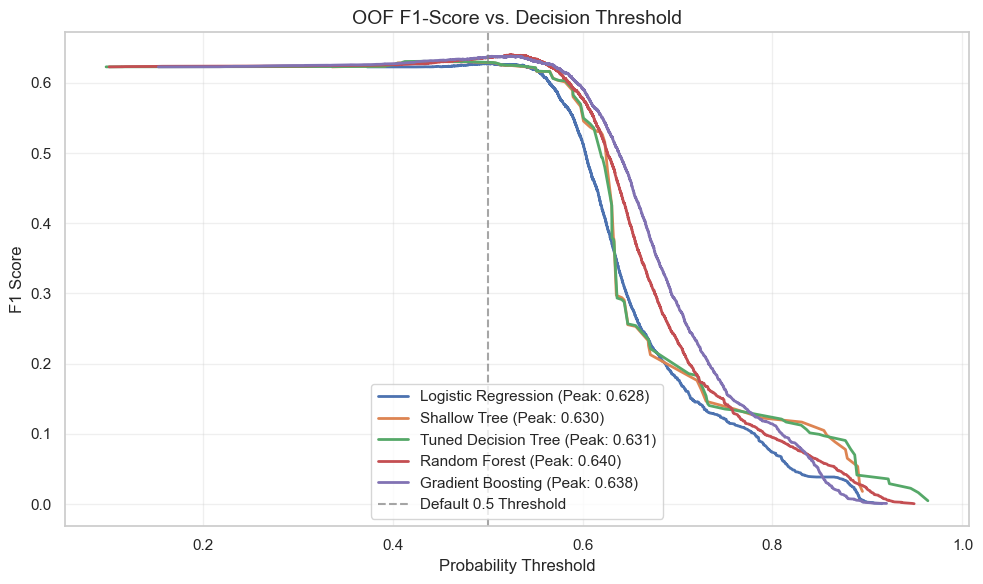

,Model,Optimal Threshold,Peak OOF F1-Score
0,Random Forest,0.5245,0.6399
1,Gradient Boosting,0.5248,0.6381
2,Tuned Decision Tree,0.4304,0.6307
3,Shallow Tree,0.4455,0.6302
4,Logistic Regression,0.5045,0.6275


In [50]:
print("Generating OOF predictions and metrics...")

oof_predictions_dict = {}
model_results = []
fold_metrics_list = []

plt.figure(figsize=(10, 6))

for name, pipeline in candidate_models.items():
    # 1. Gather OOF Probabilities
    oof_probs = cross_val_predict(
        pipeline, X_train, y_train, cv=cv5, method="predict_proba", n_jobs=-1
    )[:, 1]
    oof_predictions_dict[name] = oof_probs
    
    # 2. Gather Fold-by-Fold metrics (for the swarm plots later)
    f05_scorer = make_scorer(fbeta_score, beta=0.5)
    cv_scores = cross_validate(pipeline, X_train, y_train, cv=cv5, scoring={'fbeta': f05_scorer, 'log_loss': 'neg_log_loss'})

    for fold_idx in range(cv5.get_n_splits()):
        fold_metrics_list.append({
            "Model": name,
            "Fold": fold_idx + 1,
            "F1 Score (Default 0.5)": cv_scores['test_fbeta'][fold_idx],
            "Neg Log-Loss": cv_scores['test_log_loss'][fold_idx]
        })
    
    # 3. Calculate Optimal Threshold
    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)

    beta = 0.5
    beta_sq = beta ** 2
    numerator = (1 + beta_sq) * (precisions * recalls)
    denominator = (beta_sq * precisions) + recalls
    fbeta_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
    
    best_idx = np.argmax(fbeta_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = fbeta_scores[best_idx]
    
    model_results.append({
        "Model": name,
        "Optimal Threshold": best_threshold,
        "Peak OOF F1-Score": best_f1
    })
    
    # Plot Threshold vs F1
    plt.plot(thresholds, fbeta_scores[:-1], label=f"{name} (Peak: {best_f1:.3f})", linewidth=2)

# Format the Threshold vs F1 Plot
plt.title("OOF F1-Score vs. Decision Threshold", fontsize=14)
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label="Default 0.5 Threshold")
plt.legend(loc="lower center")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display Summary Scorecard
summary_df = pd.DataFrame(model_results).sort_values(by="Peak OOF F1-Score", ascending=False)
display(summary_df.round(4).reset_index(drop=True))

# Extract winning details
best_model_name = summary_df.iloc[0]["Model"]
best_threshold = summary_df.iloc[0]["Optimal Threshold"]
winning_pipeline = candidate_models[best_model_name]

# Store CV metrics df
cv_metrics_df = pd.DataFrame(fold_metrics_list)


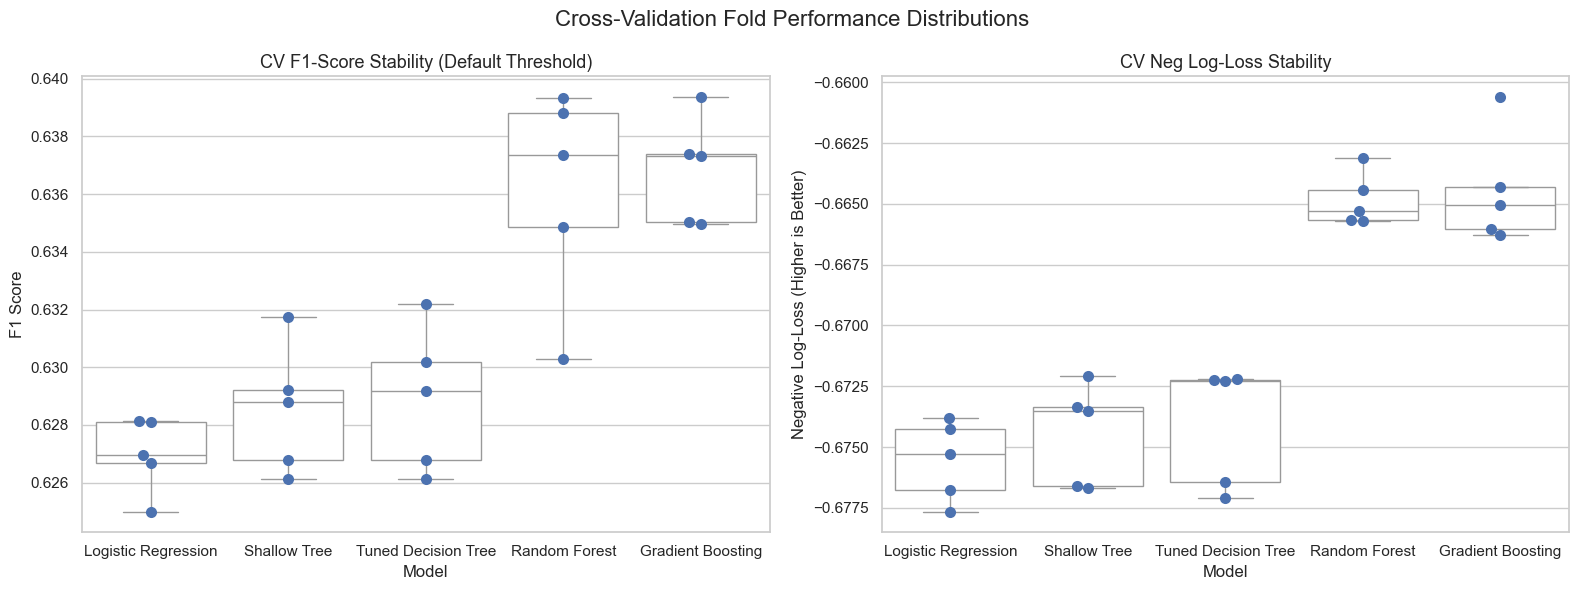

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: F1 Score (Default threshold) variance
sns.boxplot(data=cv_metrics_df, x="Model", y="F1 Score (Default 0.5)", color="white", ax=axes[0])
sns.swarmplot(data=cv_metrics_df, x="Model", y="F1 Score (Default 0.5)", size=8, ax=axes[0])
axes[0].set_title("CV F1-Score Stability (Default Threshold)", fontsize=13)
axes[0].set_ylabel("F1 Score")

# Subplot 2: Negative Log-Loss variance
sns.boxplot(data=cv_metrics_df, x="Model", y="Neg Log-Loss", color="white", ax=axes[1])
sns.swarmplot(data=cv_metrics_df, x="Model", y="Neg Log-Loss", size=8, ax=axes[1])
axes[1].set_title("CV Neg Log-Loss Stability", fontsize=13)
axes[1].set_ylabel("Negative Log-Loss (Higher is Better)")

plt.suptitle("Cross-Validation Fold Performance Distributions", fontsize=16)
plt.tight_layout()
plt.show()

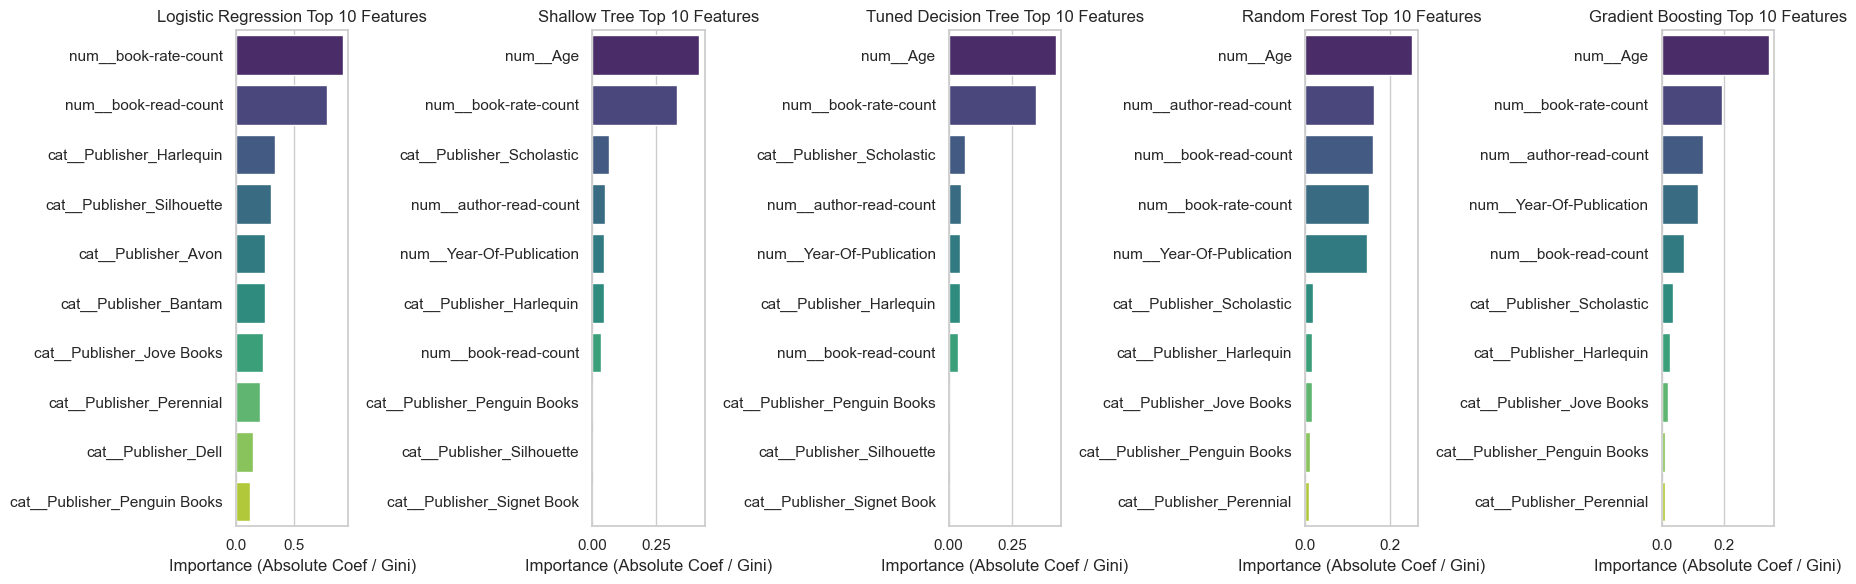

In [52]:
#  Feature Importances
# Fit all models on the full training set to extract and plot their most important features.

# %%
fig, axes = plt.subplots(1, len(candidate_models), figsize=(18, 6))

for idx, (name, pipeline) in enumerate(candidate_models.items()):
    # Fit the pipeline on the full training data
    pipeline.fit(X_train, y_train)
    
    # Extract feature names from the preprocessor (handles OneHotEncoded names)
    preprocessor = pipeline.named_steps['pre']
    model = pipeline.named_steps['model']
    feature_names_out = preprocessor.get_feature_names_out()
    
    # Extract importances (coefficients for Linear, importances for Trees)
    if hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        importances = model.feature_importances_
        
    # Sort and plot top 10
    feat_df = pd.DataFrame({'Feature': feature_names_out, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)
    
    sns.barplot(data=feat_df, x='Importance', y='Feature', ax=axes[idx], palette="viridis")
    axes[idx].set_title(f"{name} Top 10 Features")
    axes[idx].set_xlabel("Importance (Absolute Coef / Gini)")
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()

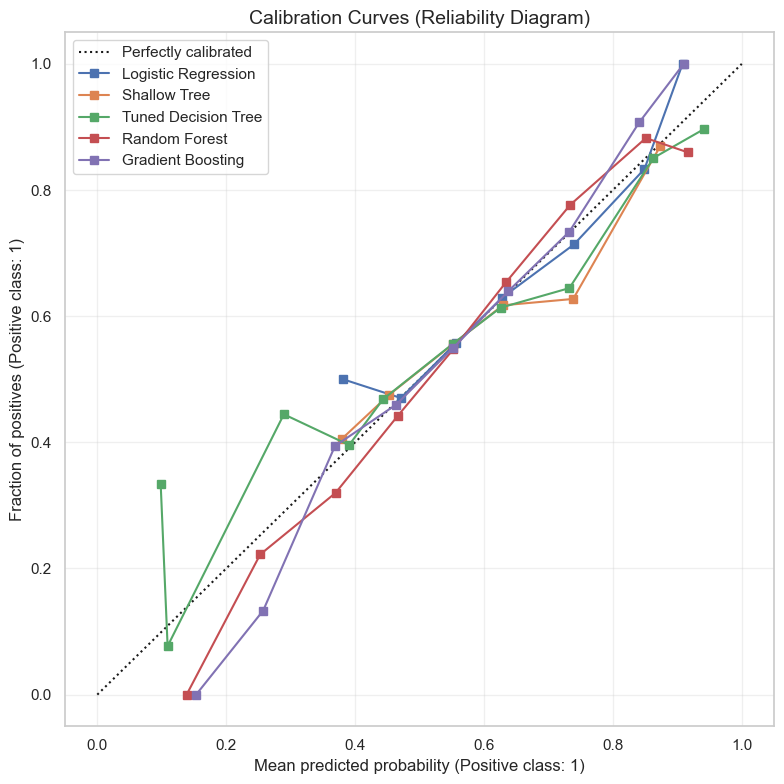

In [53]:
# Model Reliability (Calibration Curve)
# Ensure the out-of-fold predicted probabilities match actual observed frequencies.

plt.figure(figsize=(8, 8))
ax = plt.gca()

for name in candidate_models.keys():
    # We use the OOF probabilities calculated in Cell 4
    CalibrationDisplay.from_predictions(
        y_train, 
        oof_predictions_dict[name], 
        n_bins=10, 
        name=name, 
        ax=ax
    )

plt.title("Calibration Curves (Reliability Diagram)", fontsize=14)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


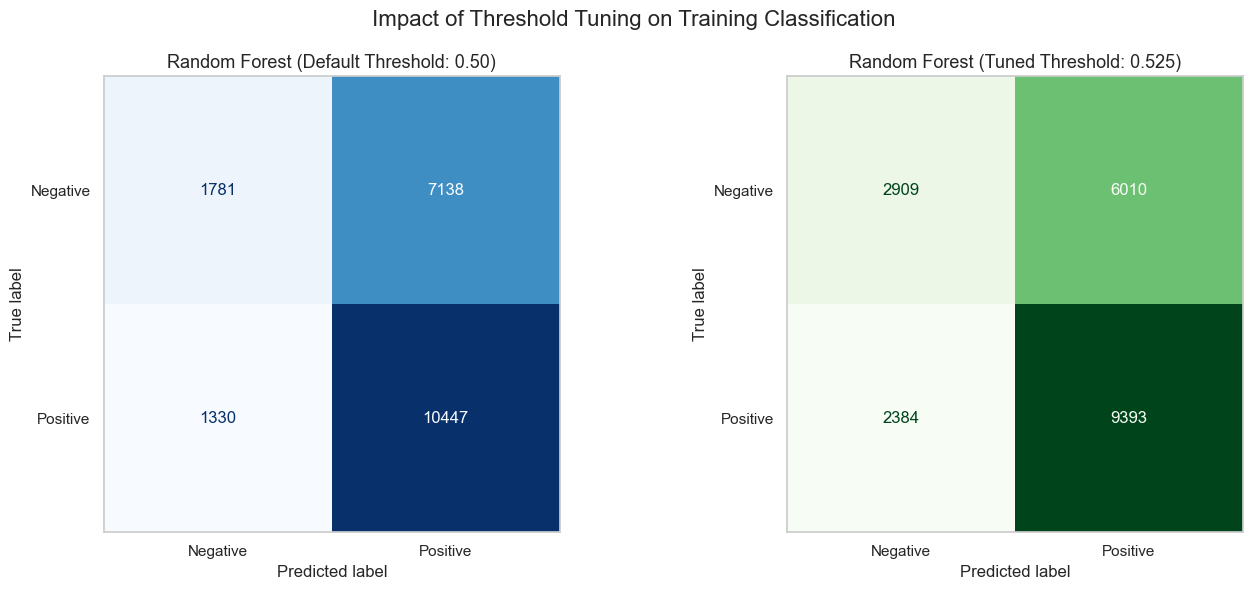

Done! The final 'Random Forest' pipeline is stored in `winning_pipeline`.
Remember to use (winning_pipeline.predict_proba(X_test)[:, 1] >= 0.525).astype(int) for future predictions!


In [54]:
# The Winning Model & Tuned Confusion Matrix
# optimized threshold redistributes errors for the winning model

# Extract winning OOF probabilities
winning_oof_probs = oof_predictions_dict[best_model_name]

# 1. Predict using default 0.5 threshold
y_pred_default = (winning_oof_probs >= 0.5).astype(int)

# 2. Predict using our tuned threshold
y_pred_tuned = (winning_oof_probs >= best_threshold).astype(int)

# Plot both to show the difference
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_default = confusion_matrix(y_train, y_pred_default)
ConfusionMatrixDisplay(cm_default, display_labels=["Negative", "Positive"]).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d'
)
axes[0].set_title(f"{best_model_name} (Default Threshold: 0.50)", fontsize=13)
axes[0].grid(False)

cm_tuned = confusion_matrix(y_train, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned, display_labels=["Negative", "Positive"]).plot(
    ax=axes[1], cmap='Greens', colorbar=False, values_format='d'
)
axes[1].set_title(f"{best_model_name} (Tuned Threshold: {best_threshold:.3f})", fontsize=13)
axes[1].grid(False)

plt.suptitle("Impact of Threshold Tuning on Training Classification", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Done! The final '{best_model_name}' pipeline is stored in `winning_pipeline`.")
print(f"Remember to use (winning_pipeline.predict_proba(X_test)[:, 1] >= {best_threshold:.3f}).astype(int) for future predictions!")


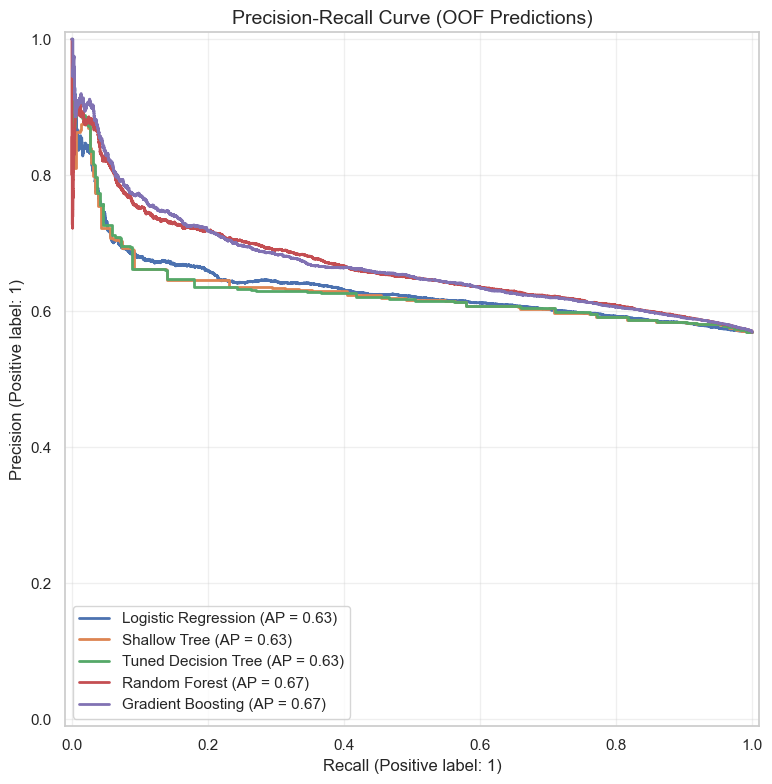

In [55]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

for name in candidate_models.keys():
    # Plot the PR curve using our OOF probabilities
    PrecisionRecallDisplay.from_predictions(
        y_train, 
        oof_predictions_dict[name], 
        name=name, 
        ax=ax,
        linewidth=2
    )

plt.title("Precision-Recall Curve (OOF Predictions)", fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()